# Kriging workflow

Kriging turns **scattered point observations** into a **continuous surface plus an uncertainty estimate**. The
pipeline is always the same:

**explore spatial structure → fit a variogram → krige onto a grid → validate honestly.**

Everything hangs off `Samples`, a `FeatureCollection` subclass, so the column to interpolate is always a method
argument. This notebook walks the full pipeline on a synthetic rain-gauge field.

In [1]:
%matplotlib inline
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
from geostatista import Samples

# A smooth spatial field (two sinusoids) sampled at 80 random gauge locations, in metres (UTM 33N).
rng = np.random.default_rng(0)
xy = rng.uniform(0.0, 100.0, (80, 2))
rain = np.sin(xy[:, 0] / 25.0) * np.cos(xy[:, 1] / 25.0) * 10.0 + 20.0
gdf = gpd.GeoDataFrame({"rain": rain}, geometry=[Point(x, y) for x, y in xy], crs="EPSG:32633")

samples = Samples(gdf)          # a Samples *is-a* FeatureCollection
samples.head()

2026-07-18 20:18:56 | INFO | pyramids.base.config | Logging is configured.


,rain,geometry
0,22.641148,POINT (63.696 26.979)
1,21.628049,POINT (4.097 1.653)
2,20.971303,POINT (81.327 91.276)
3,13.606683,POINT (60.664 72.95)
4,13.199467,POINT (54.362 93.507)


`Samples` exposes two convenience accessors that validate the geometry, drop `NaN` rows, and hand back plain
NumPy — the exact `(coords, values)` every geostatistics routine consumes.

In [2]:
print("values[:5] :", np.round(samples.values("rain")[:5], 2))
print("coords[:3] :\n", np.round(samples.coords("rain")[:3], 2))

values[:5] : [22.64 21.63 20.97 13.61 13.2 ]
coords[:3] :
 [[63.7  26.98]
 [ 4.1   1.65]
 [81.33 91.28]]


## 1. Empirical variogram — look before you krige

The empirical variogram bins pairwise squared differences by lag distance: it shows how quickly the field
de-correlates with separation. `semivariance` rises from near zero and flattens out around the *sill*.

In [3]:
vg = samples.variogram("rain", n_lags=12)     # estimator="matheron" by default
vg.to_dataframe()                              # lag / semivariance / count

,lag,semivariance,count
0,2.916256,0.407096,31
1,8.748767,1.766324,90
2,14.581278,4.317994,120
3,20.413789,8.052968,141
4,26.246301,11.778970,186
5,32.078812,13.569288,215
6,37.911323,16.944426,251
7,43.743834,24.814935,247
8,49.576345,30.381390,237
9,55.408857,29.178667,239


Plotting needs the `viz` extra (cleopatra). Before fitting, `Variogram.plot` shows just the empirical cloud.

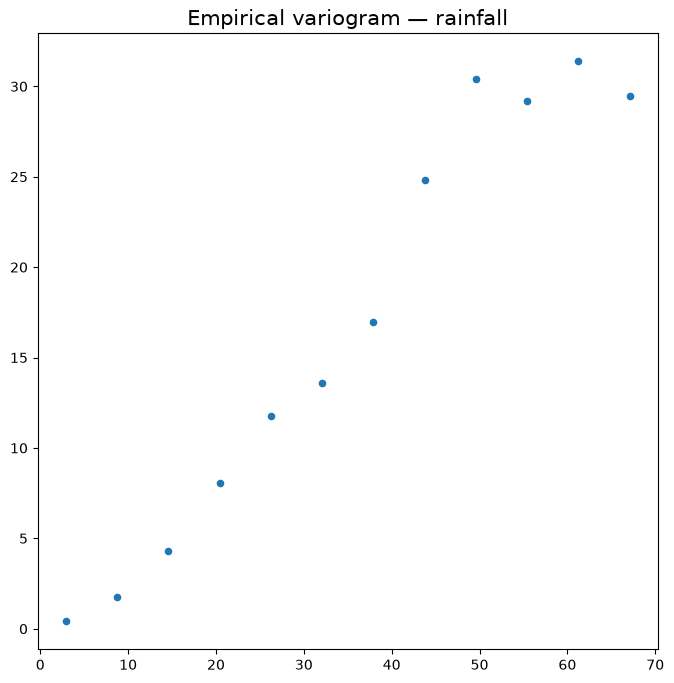

In [4]:
fig, ax = vg.plot(title="Empirical variogram — rainfall")

## 2. Fit a model — the (nugget, sill, range) triple kriging needs

Kriging needs a valid, positive-definite model, not the raw cloud. Choose `spherical`, `exponential`, `gaussian`,
or `matern`. Fitting sets `.nugget`, `.sill`, and `.range_`, and returns the variogram for chaining.

In [5]:
vg.fit(model="spherical")
print(vg)
print("gamma(0)  =", round(float(vg.predict(0.0)), 3))
print("gamma(30) =", round(float(vg.predict(30.0)), 3), " (near the sill)")

<Variogram model='spherical' nugget=8.295e-32 sill=62.76 range=181.3>
gamma(0)  = 0.0
gamma(30) = 15.435  (near the sill)


Now `Variogram.plot` overlays the fitted model curve on the empirical cloud.

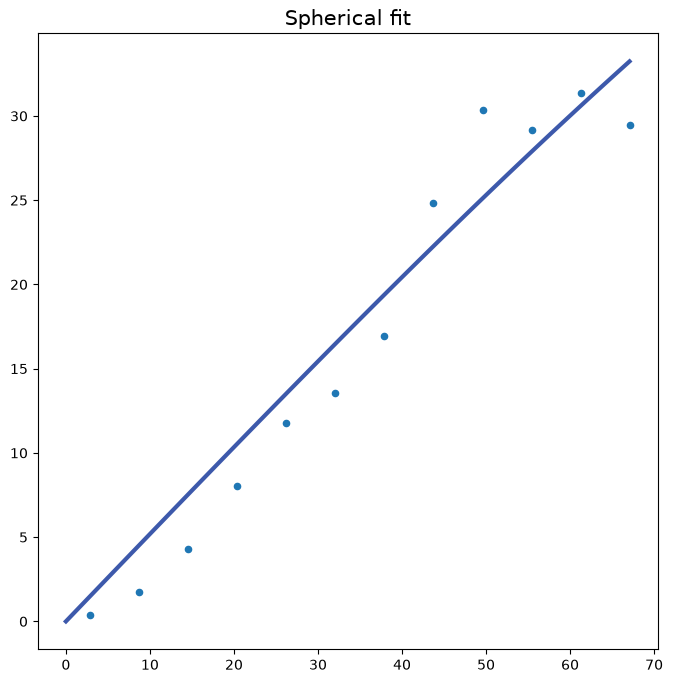

In [6]:
fig, ax = vg.plot(title="Spherical fit")

## 3. Krige onto a grid — a 2-band surface (estimate + variance)

`krige` (an alias for `interpolate_to_raster(method="kriging")`) returns a `KrigedSurface`: a 2-band `Dataset`
where **band 0 is the estimate** and **band 1 is the kriging variance**. `n_neighbors` bounds the moving
neighborhood around each target cell — the key to scaling past a few thousand samples.

In [7]:
surface = samples.krige("rain", vg, cell_size=5.0, n_neighbors=24)
arr = np.asarray(surface.read_array())
print("bands :", surface.band_count, " epsg :", surface.epsg, " shape :", arr.shape)
print("estimate range :", round(arr[0].min(), 2), "->", round(arr[0].max(), 2))
print("variance >= 0 everywhere :", bool(np.all(arr[1] >= -1e-9)))

bands : 2  epsg : 32633  shape : (2, 20, 20)
estimate range : 10.22 -> 28.9
variance >= 0 everywhere : True


Map the estimate and — the reason to prefer kriging over IDW — the uncertainty band. The variance is lowest near
the gauges and grows where the surface is extrapolated.

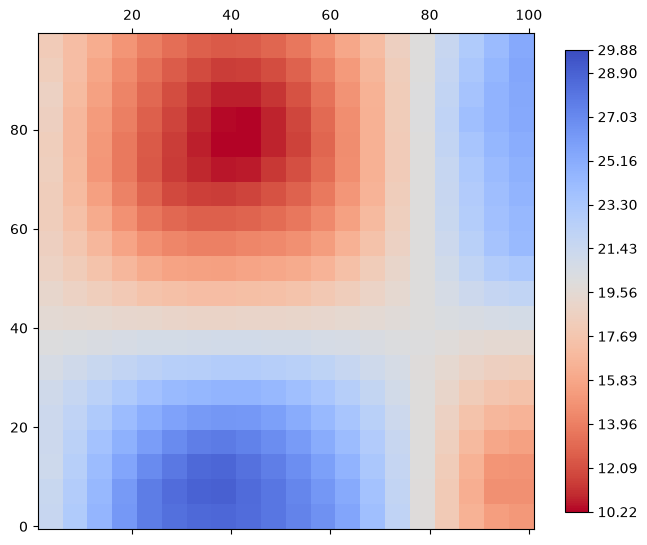

In [8]:
est_glyph = surface.estimate.plot()      # band 0 — the interpolated surface

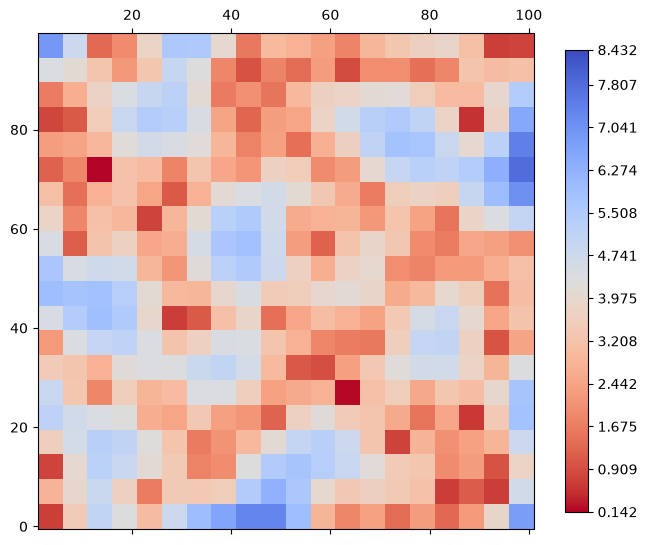

In [9]:
var_glyph = surface.variance.plot()      # band 1 — where the estimate is least certain

The surface is **self-describing**: the producing variogram is stored as typed attributes and written to the
raster's metadata tags (`GS_*`), so a saved GeoTIFF round-trips its own provenance.

In [10]:
# The producing variogram is carried as typed attributes and mirrored into the raster metadata tags, so
# `surface.to_file("rain.tif")` yields a 2-band GeoTIFF that describes its own provenance.
print("provenance:", surface.model, "nugget=%.3g" % surface.nugget,
      "sill=%.3g" % surface.sill, "range=%.3g" % surface.range_)
{k: v for k, v in surface.meta_data.items() if k.startswith("GS_")}

provenance: spherical nugget=8.29e-32 sill=62.8 range=181


{'GS_CLASS': 'KrigedSurface',
 'GS_MODEL': 'spherical',
 'GS_NUGGET': '8.294908491270433e-32',
 'GS_SILL': '62.76224324297655',
 'GS_RANGE': '181.3106285731835',
 'GS_NEIGHBORS': '24'}

## 4. The convenient variants — auto-fit, a template grid, and IDW

You can skip the explicit `Variogram` and pass a **model name** to auto-fit it internally; align the output grid
to an existing `Dataset` with `template=`; or fall back to inverse-distance weighting with `method="idw"` (which
delegates to pyramids — see [ADR 0001](../adr/0001-pyramids-geostatista-boundary.md)).

In [11]:
# (a) auto-fit an exponential model by name — no explicit Variogram object
auto = samples.krige("rain", "exponential", cell_size=5.0)
print("auto-fit surface :", auto.model, " bands :", auto.band_count)

# (b) align a new kriging to the grid of an existing Dataset
aligned = samples.krige("rain", vg, template=surface.estimate)
print("template-aligned :", np.asarray(aligned.read_array()).shape, "==", arr.shape[1:])

# (c) inverse-distance weighting instead of kriging (single band, no variance)
idw = samples.interpolate_to_raster("rain", method="idw", cell_size=5.0)
print("idw surface bands :", idw.band_count)

auto-fit surface : exponential  bands : 2


template-aligned : (2, 20, 20) == (20, 20)


idw surface bands : 1


### Under the hood — the `OrdinaryKriging` engine

`Samples.krige` drives an `OrdinaryKriging` engine you can also use directly for single-point predictions.

In [12]:
from geostatista import OrdinaryKriging

engine = OrdinaryKriging(samples.coords("rain"), samples.values("rain"), vg, n_neighbors=16)
estimate, variance = engine.predict_point(np.array([50.0, 50.0]))
print("estimate at (50, 50) :", round(estimate, 3), " kriging variance :", round(variance, 3))

estimate at (50, 50) : 16.587  kriging variance : 4.285


## 5. Validate honestly — leave-one-out cross-validation

Cross-validation drops each point in turn, krige-predicts it from the rest, and reports the errors. For a
well-specified variogram the **mean standardized error ≈ 0** and the **standardized RMSE ≈ 1**.

In [13]:
cv = samples.cross_validate("rain", vg, n_neighbors=None)   # None -> exact global solve
cv.head()

,observed,predicted,error,kriging_variance,standardized_error
0,22.641148,22.468145,-0.173003,4.577535,-0.080861
1,21.628049,23.361794,1.733745,8.949332,0.579549
2,20.971303,20.978955,0.007652,1.417721,0.006427
3,13.606683,13.925067,0.318384,4.867746,0.144307
4,13.199467,13.285727,0.086260,3.732911,0.044646


In [14]:
{k: round(v, 4) for k, v in cv.attrs["summary"].items()}

{'ME': -0.0311,
 'RMSE': 0.5056,
 'mean_standardized_error': -0.0076,
 'RMSE_standardized': 0.2084,
 'correlation': 0.9948}

That is the whole pipeline: **variogram → fit → krige (estimate + variance) → cross-validate**, all as methods on
`Samples`. See the [variogram-models notebook](03_variogram_models.ipynb) for choosing between models, and the
[spatial-autocorrelation notebook](02_spatial_autocorrelation.ipynb) for the other half of the package.